# Time for things to start get interesting...so what is a filter?

One of the most important concepts in all of navigation is **filters**. In simple terms, a filter is basically an algorithm that takes super messy data (which is what most sensor data is) and tries to produce a cleaner or more useful version of it (which is what you really want).

The sensors in any tech, whether its an Iphone, the laptop you're reading this on, or more importantly, MIDAS, are not perfect. An altimeter, IMU, GPS, pressure sensor, etc. will all have some varying level of noise. If we trusted every measurement exactly as it came in, our estimate of the rocket's state would jump around like crazy. Look at this...this is from an arduino (with an MPU6050 which is an accelerometer) just laying flat on the table: 

![Alternative text](mpu6050_noise.png)

A filter gives us a true estimate based on **what we measured with what we already believe is happening.**

In simple words:

- Measurements are noisy
- Filters smooth or estimate signals
- The goal is not always to remove all motion
- The goal is usually to remove the random garbage while keeping the real trend

We will talk about the anticipated Kalman Filter next module. This is just the stepping stone. Trust me...the Kalman Filter will become trivial after this. 

### First lets make some fake flight data.

Suppose our rocket is ascending up, and our sensor measures altitude. From physics you know the true altitude is smooth (lets ignore drag for *now*), but the measurement has noise added to it.

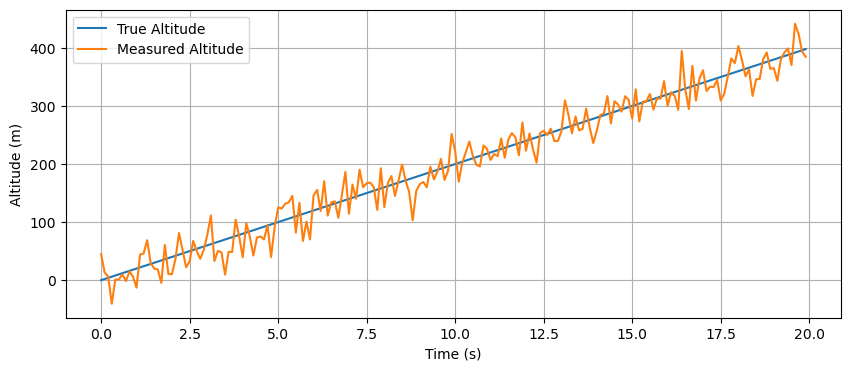

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

time = np.arange(0, 20, 0.1)
true_altitude = 20 * time
noise = np.random.normal(0, 25, len(time))
measured_altitude = true_altitude + noise

plt.figure(figsize=(10, 4))
plt.plot(time, true_altitude, label="True Altitude")
plt.plot(time, measured_altitude, label="Measured Altitude")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

You don't generally know your true altitude and only rely on the measurements coming in from your sensors. Notice how the measured altitude is generally increasing, but its super noisy. The filter's job is to make that measurement actually usable and produce an estimated altitude that can match the true one.

**Moving Average Filter**

The moving average filter is probably the easiest filter to understand.

Instead of trusting one measurement, we average the last few measurements.

For example, if we're developing a 3 sample moving average filter and our last 3 measurements are:

$z = [100, 110, 90]$

then the moving average is:

$\frac{100 + 110 + 90}{3} = 100$

This helps smooth out random spikes.

Now in python....

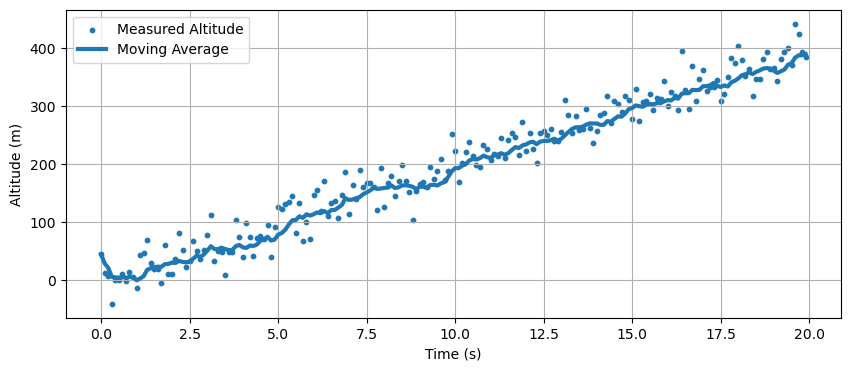

In [3]:
def moving_average(data, window_size):
    filtered_data = []

    for i in range(len(data)):
        start_index = max(0, i - window_size + 1)
        window = data[start_index:i+1]
        filtered_data.append(np.mean(window))

    return np.array(filtered_data)

moving_average_altitude = moving_average(measured_altitude, 10)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, moving_average_altitude, label="Moving Average", linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

The moving average looks smoother, but there is a tradeoff.

If we average too many points, the filter becomes smoother but also slower to react.

This delay is called **lag**. You will see this tradeoff alot in GNC.

### 🎯 Your Turn

Change the `window_size` below.

Try:

- 3
- 10
- 30

What happens when the window gets larger?


Set it to whichever window you found most interesting before you check — left on the 3 it came with, it reads as *not tried yet*. Keep the `filtered = ...` line and the plot below it: those are what the check reads.

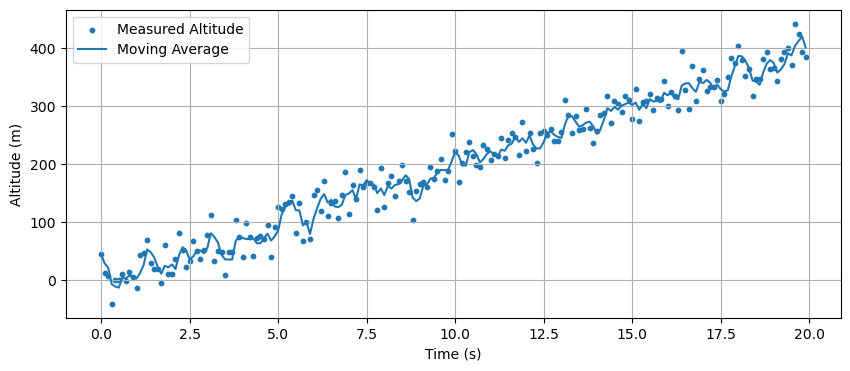

In [ ]:
### BEGIN STUB
window_size = 3
### END STUB
### BEGIN SOLUTION
window_size = 10
### END SOLUTION

filtered = moving_average(measured_altitude, window_size)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, filtered, label="Moving Average")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

**Low-Pass Filter**

A low-pass filter lets slow changes go through, while reducing fast changes. So less spikes! 

That sounds complicated, but all it means is suppose you have:

- Real rocket altitude changes smoothly
- Random sensor noise jumps around quickly

**A low-pass filter keeps that smooth part and reduces (not eliminate) the jumpy part**

A simple low-pass filter looks like:

$filtered_k = \alpha measurement_k + (1 - \alpha) filtered_{k-1}$

Where $\alpha$ controls how much we trust the newest measurement.

If $\alpha$ is large, we trust the measurement more.

If $\alpha$ is small, we trust our previous filtered value more.

This sounds awesome! But theres reasons why you wouldn't want to use this. Here's some food for thought...suppose you're developing a racing drone thats making super fast movements. In this case the rapid jumps in your data *are actually useful information.* The low pass filter just couldn't work. Additionally, they are by design going to lag behind...which you may not want. 

Now in python....

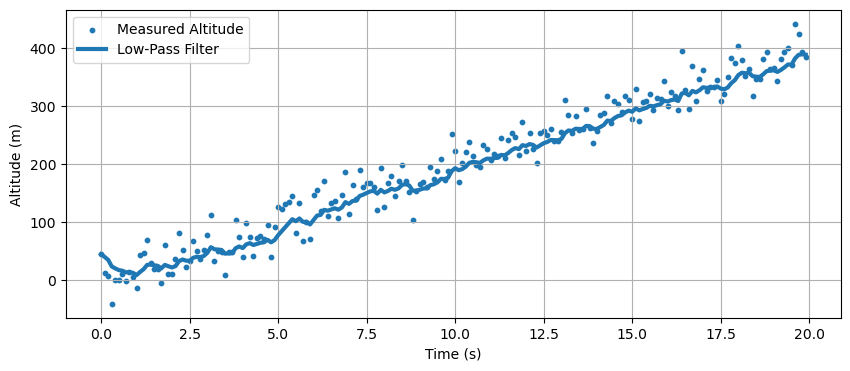

In [5]:
def low_pass_filter(data, alpha):
    filtered_data = []
    filtered_value = data[0]

    for measurement in data:
        filtered_value = alpha * measurement + (1 - alpha) * filtered_value
        filtered_data.append(filtered_value)

    return np.array(filtered_data)

low_pass_altitude = low_pass_filter(measured_altitude, alpha=0.15)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, low_pass_altitude, label="Low-Pass Filter", linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

### 🎯 Your Turn

Change `alpha` below.

Try values like:

- 0.05
- 0.2
- 0.8

Which one is smoother? Which one reacts faster?


Same as before: leave `alpha` on whichever value you found most interesting rather than the 0.2 it came with, and keep the `filtered = ...` line and the plot.

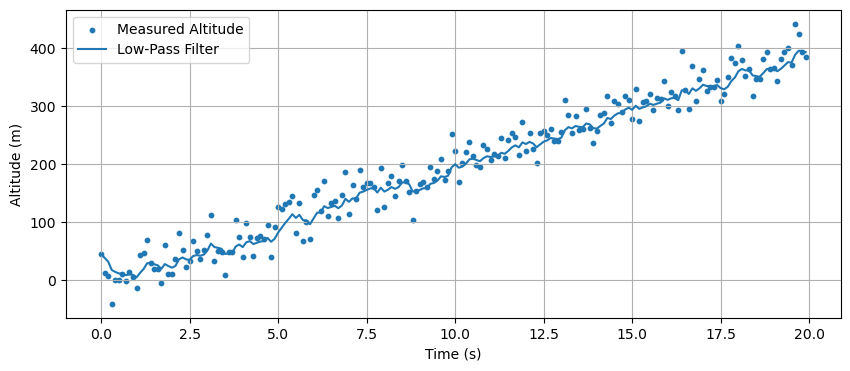

In [6]:
### BEGIN STUB
alpha = 0.2
### END STUB
### BEGIN SOLUTION
alpha = 0.05
### END SOLUTION

filtered = low_pass_filter(measured_altitude, alpha)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, filtered, label="Low-Pass Filter")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()

**Lets add a GNC flair...Alpha Filter**

An alpha filter is basically the same as the low-pass filter, but written in a way that starts to look more like how you see it in GNC literature.

We have:

- A measurement $z$
- An estimate $\hat{x}$
- A correction based on the error

The equation is:

$\hat{x}_{new} = \hat{x}_{old} + \alpha(z - \hat{x}_{old})$

The term $(z - \hat{x}_{old})$ is called the residual or error.

It asks: how far away was my estimate from the measurement?

Get familiar with this notation, it'll be used a TON! You'll notice the hat in top of a variable. All that means is that the value is an *estimated or predicted* value. We never definitively know the true value of what we are attempting to predict/filter, thus it will always be an estimate. 

**Alpha Beta Gamma Filter**

Okay now lets make it a little more useful as well as closer to what happens on our team. 

The alpha filter only estimates position (1 variable). But for a rocket, we usually care about:

- Position
- Velocity
- Acceleration

The alpha beta gamma filter estimates all three. This time, lets assume we have an accelerometer (a sensor that measures acceleration). MIDAS will use this! 

The idea is:

1. Predict where the rocket should be using position, velocity, and acceleration
2. Compare that prediction to the measurement
3. Correct position, velocity, and acceleration using the error

This starts to look alot like the structure of a kalman filter (next module you'll see the similarity), just without the matrix probability stuff yet.

From physics you know that for constant acceleration motion, the kinematic equations are:

$x_{pred} = x_{k-1} + v_{k-1}\Delta t + \frac{1}{2}a_{k-1}\Delta t^2$

$v_{pred} = v_{k-1} + a_{k-1}\Delta t$

$a_{pred} = a_{k-1}$

Then we compute the residual (remember we are using acceleration now):

$residual = a_{measurement} - a_{pred}$

Recall...based on finite differences to convert: 

acceleration to velocity:
$\Delta v = a_{k-1}{\Delta t}$

acceleration to position:
$\Delta x = \frac{1}{2}a_{k-1}\Delta t^2 $

Now, assuming using this fact and our residuals, we can apply our $\alpha, \beta, \gamma$ factors and correct:

$x = x_{pred} + \alpha (0.5\Delta t^2 \cdot residual)$

$v = v_{pred} + \beta (\Delta t \cdot residual)$

$a = a_{pred} + \gamma (residual)$

Something that may be confusing is why the velocity component was not factored in for the position correction. That contribution is already taken into account from the $x_{pred}$. When correcting we only care about converting the **state** (acceleration to position) of our measurement using an **update step** (correction). This wording is GNC lingo for what we did here.

Now in python....

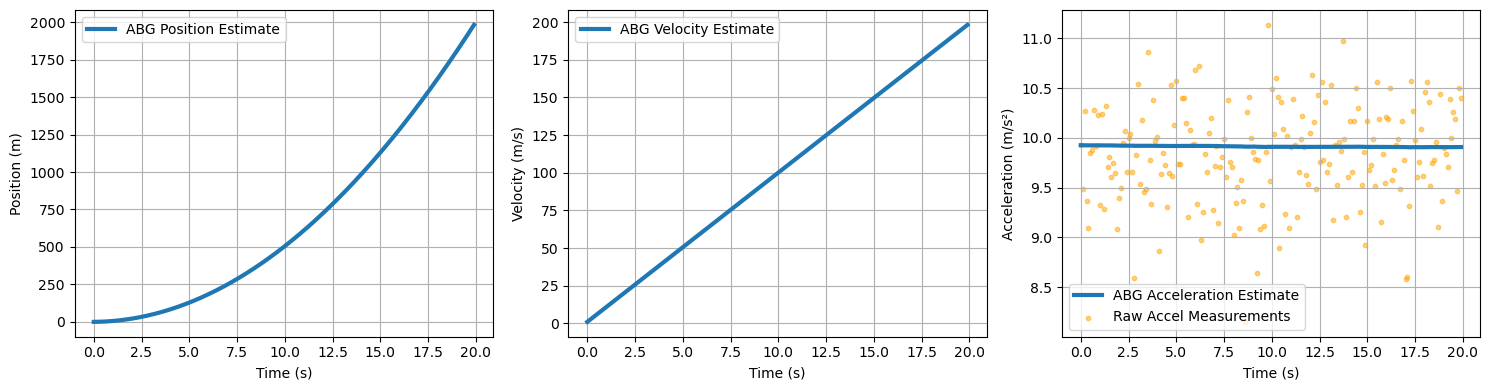

In [ ]:
time = np.arange(0, 20, 0.1)
true_accel = 9.81 * np.ones_like(time)  # Constant acceleration due to gravity
noise = np.random.normal(0, 0.5, len(time))
measured_acceleration = true_accel + noise

def alpha_beta_gamma_filter(measurements, dt, alpha, beta, gamma):
    positions = []
    velocities = []
    accelerations = []

    position = 0
    velocity = 0
    acceleration = measurements[0]  

    for z in measurements:
        predicted_position = position + velocity * dt + 0.5 * acceleration * dt**2
        predicted_velocity = velocity + acceleration * dt
        predicted_acceleration = acceleration

        residual = z - predicted_acceleration

        position = predicted_position + alpha * (0.5 * dt**2) * residual
        velocity = predicted_velocity + beta * dt * residual
        acceleration = predicted_acceleration + gamma * residual

        positions.append(position)
        velocities.append(velocity)
        accelerations.append(acceleration)

    return np.array(positions), np.array(velocities), np.array(accelerations)

dt = 0.1
position_estimate, velocity_estimate, acceleration_estimate = alpha_beta_gamma_filter(
    measured_acceleration,
    dt,
    alpha=0.3,
    beta=0.05,
    gamma=0.001
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))  
ax1.plot(time, position_estimate, label="ABG Position Estimate", linewidth=3)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position (m)")
ax1.grid(True)
ax1.legend()

ax2.plot(time, velocity_estimate, label="ABG Velocity Estimate", linewidth=3)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Velocity (m/s)")
ax2.grid(True)
ax2.legend()

ax3.plot(time, acceleration_estimate, label="ABG Acceleration Estimate", linewidth=3)
ax3.scatter(time, measured_acceleration, s=10, alpha=0.5, color='orange', label="Raw Accel Measurements")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Acceleration (m/s²)")
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()


Now we have an estimated position, velocity, and acceleration.

Remember, the sensor only measured acceleration. The filter gave us velocity and positions estimates from how the acceleration measurement came in.

This is very useful in navigation. We took noisy acceleration measurements and converted them to a whole state profile. 

### 🎯 Your Turn

Change `alpha`, `beta`, and `gamma` in the alpha beta gamma filter.

Try to answer:

- What happens if alpha is larger?
- What happens if beta is larger?
- What happens if gamma is too large?

You do not need perfect values. Just get a feel for how the filter reacts.


Change at least one of the three before you check, and keep the `position_estimate, velocity_estimate, acceleration_estimate = ...` unpacking. Leave `dt` alone — that is the sensor's sample spacing (0.1 s), not a tuning knob.

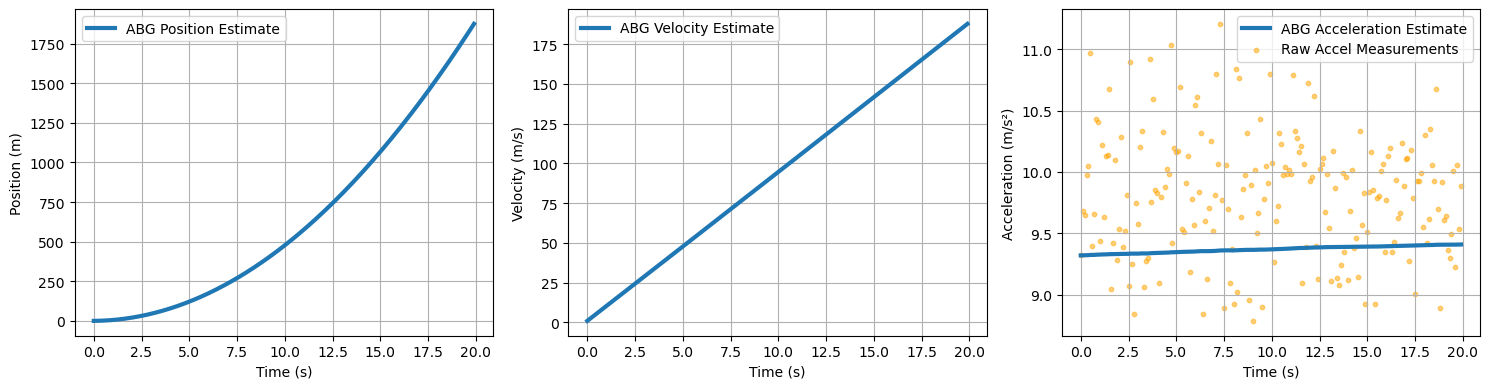

In [23]:
# Write your code here

### BEGIN STUB
ALPHA = 0.3
BETA  = 0.05
GAMMA = 0.001
### END STUB
### BEGIN SOLUTION
ALPHA = 0.6
BETA  = 0.20
GAMMA = 0.010
### END SOLUTION

dt = 0.1

position_estimate, velocity_estimate, acceleration_estimate = alpha_beta_gamma_filter(
    measured_acceleration,
    dt,
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))  # Expanded width to fit 3 subplots cleanly
ax1.plot(time, position_estimate, label="ABG Position Estimate", linewidth=3)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position (m)")
ax1.grid(True)
ax1.legend()

ax2.plot(time, velocity_estimate, label="ABG Velocity Estimate", linewidth=3)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Velocity (m/s)")
ax2.grid(True)
ax2.legend()

ax3.plot(time, acceleration_estimate, label="ABG Acceleration Estimate", linewidth=3)
ax3.scatter(time, measured_acceleration, s=10, alpha=0.5, color='orange', label="Raw Accel Measurements")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Acceleration (m/s²)")
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()



### 🚀 Challenge:  Filtering Rocket Altitude

A rocket altitude sensor gives the noisy measurements below.

Your Tasks:

- Create a moving average filter with a window size of 5
- Create a low-pass filter with alpha = 0.2
- Create an alpha filter with alpha = 0.2
- Plot all three filtered signals with the original measurements
- Which one looks smoothest?
- Which one seems to react fastest?

This is the main tradeoff filters usually make: smoothness vs. reaction speed. Think about how we can instead use a position measurement to produce acceleration and velocity. 


Store each filter's output in its own variable so all three can go on the plot, and filter `measured_altitude` — `true_altitude` is only there so you can see how close you got.

In [12]:
#% checker: filter_the_altitude
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

time = np.arange(0, 15, 0.1)
true_altitude = 15 * time + 0.5 * time**2
measured_altitude = true_altitude + np.random.normal(0, 20, len(time))

# Write your code here
### BEGIN SOLUTION

window_size = 5
alpha = 0.2

moving_average_altitude = moving_average(measured_altitude, window_size)
low_pass_estimate = low_pass_filter(measured_altitude, alpha)

# The alpha filter is the same recursion written the GNC way:
# x_new = x_old + alpha * (z - x_old).
alpha_filter_estimate = []
estimate = measured_altitude[0]
for z in measured_altitude:
    estimate = estimate + alpha * (z - estimate)
    alpha_filter_estimate.append(estimate)
alpha_filter_estimate = np.array(alpha_filter_estimate)

plt.figure(figsize=(10, 4))
plt.scatter(time, measured_altitude, s=10, label="Measured Altitude")
plt.plot(time, moving_average_altitude, label="Moving Average (window 5)", linewidth=2)
plt.plot(time, low_pass_estimate, label="Low-Pass (alpha 0.2)", linewidth=2)
plt.plot(time, alpha_filter_estimate, label="Alpha Filter (alpha 0.2)", linewidth=2, linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.legend()
plt.grid(True)
plt.show()
### END SOLUTION

**Summary**

Filters are algorithms that help clean up or estimate useful information from noisy measurements.

The big idea is that filters balance trusting the measurement vs trusting the previous estimate.

If you understand that sentence, you understand the main intuition behind alot of GNC filtering. Kalman filters will build directly off this idea, but with a more formal way of deciding how much to trust each side. Okay next module...this is it! 